# Importing libs

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading datasets

In [5]:
category_tree_df = pd.read_csv('../data/raw/category_tree.csv')
events_df = pd.read_csv('../data/raw/events.csv')
item_properties_df = pd.read_csv('../data/raw/item_properties.csv')

print("Category Tree DataFrame:")
print(category_tree_df.head())
print("\nEvents DataFrame:")
print(events_df.head())
print("\nItem Properties DataFrame:")
print(item_properties_df.head())

/tmp/ipykernel_31175/1352298161.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  item_properties_df = pd.read_csv('../data/raw/item_properties.csv')


Category Tree DataFrame:
   categoryid  parentid
0         231       NaN
1         791       NaN
2        1490       NaN
3         431       NaN
4         755       NaN

Events DataFrame:
       timestamp  visitorid event  itemid  transactionid
0  1433221955914     483717  view  253185            NaN
1  1433223291897     794181  view  439202            NaN
2  1433224554732     453474  view  250696            NaN
3  1433221377547    1153198  view  388242            NaN
4  1433224266445     273888  view  205392            NaN

Item Properties DataFrame:
       timestamp  itemid property                    value
0  1440298800000   38377      501                   769062
1  1440298800000  196511      550                   769062
2  1440903600000  456233      294          1222692 1222090
3  1440903600000  345779      188  1297729 n1200.000 10317
4  1440903600000  331187      188  1297729 n1200.000 10317


# Initial data analysis and visualization

## Check missing values

In [7]:
def check_missing_values(df, df_name):
    missing_values = df.isnull().sum()
    print(f"\nMissing values in {df_name}:")
    print(missing_values)

In [8]:
check_missing_values(category_tree_df, "Category Tree DataFrame")
check_missing_values(events_df, "Events DataFrame")
check_missing_values(item_properties_df, "Item Properties DataFrame")


Missing values in Category Tree DataFrame:
categoryid     0
parentid      25
dtype: int64

Missing values in Events DataFrame:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Missing values in Item Properties DataFrame:
timestamp    0
itemid       0
property     0
value        0
dtype: int64


## Check shape of the dataframes and data types

In [9]:
# Shape of the DataFrames

print(f"\nShape of Category Tree DataFrame: {category_tree_df.shape}")
print(f"Shape of Events DataFrame: {events_df.shape}")
print(f"Shape of Item Properties DataFrame: {item_properties_df.shape}")


Shape of Category Tree DataFrame: (1669, 2)
Shape of Events DataFrame: (2756101, 5)
Shape of Item Properties DataFrame: (20275902, 4)


In [10]:
# Data types of the columns
print("\nData types of Category Tree DataFrame:")
print(category_tree_df.dtypes)
print("\nData types of Events DataFrame:")
print(events_df.dtypes)
print("\nData types of Item Properties DataFrame:")
print(item_properties_df.dtypes)


Data types of Category Tree DataFrame:
categoryid      int64
parentid      float64
dtype: object

Data types of Events DataFrame:
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Data types of Item Properties DataFrame:
timestamp     int64
itemid        int64
property     object
value        object
dtype: object


In [11]:
events_df

,timestamp,visitorid,event,itemid,transactionid
0,1433221955914,483717,view,253185,NaN
1,1433223291897,794181,view,439202,NaN
2,1433224554732,453474,view,250696,NaN
3,1433221377547,1153198,view,388242,NaN
4,1433224266445,273888,view,205392,NaN
...,...,...,...,...,...
2756096,1438401820781,1359054,view,265810,NaN
2756097,1438400304353,333944,view,235771,NaN
2756098,1438400133197,668517,view,120164,NaN
2756099,1438398088257,887677,view,415160,NaN


In [12]:
category_tree_df

,categoryid,parentid
0,231,NaN
1,791,NaN
2,1490,NaN
3,431,NaN
4,755,NaN
...,...,...
1664,1678,1698.0
1665,1034,1698.0
1666,1582,1698.0
1667,1502,1698.0


In [13]:
item_properties_df

,timestamp,itemid,property,value
0,1440298800000,38377,501,769062
1,1440298800000,196511,550,769062
2,1440903600000,456233,294,1222692 1222090
3,1440903600000,345779,188,1297729 n1200.000 10317
4,1440903600000,331187,188,1297729 n1200.000 10317
...,...,...,...,...
20275897,1431226800000,198922,categoryid,1635
20275898,1431226800000,281842,categoryid,1680
20275899,1431226800000,87566,categoryid,173
20275900,1431226800000,91501,categoryid,173


## Check Data Distribution

In [16]:
def plot_event_distribution(events_df):
    event_counts = events_df['event'].value_counts()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')
    plt.title('Distribution of Event Types')
    plt.xlabel('Event Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_31175/4212173342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')


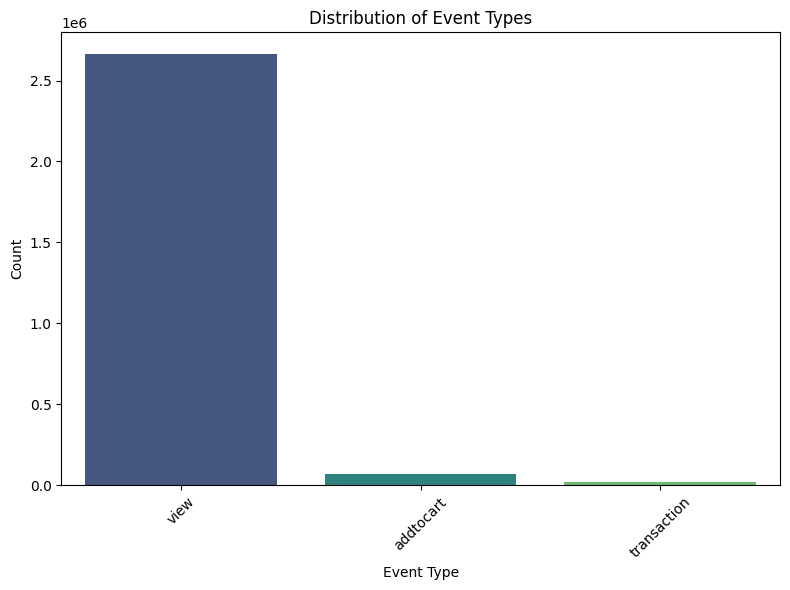

In [17]:
plot_event_distribution(events_df)

In [18]:
events_df['event'].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [23]:
item_properties_df['property'].value_counts()

property
888           2109968
available     1503639
790           1209877
888            890430
categoryid     788214
               ...   
722                 1
703                 1
424                 1
57                  1
782                 1
Name: count, Length: 2177, dtype: int64

In [25]:
# Cast property to numeric, ignpring errors to keep str
item_properties_df['property'] = pd.to_numeric(item_properties_df['property'], errors='ignore')

# Show non-numeric properties
(item_properties_df[item_properties_df['property']
                    .apply(lambda x: isinstance(x, str))]['property']
                    .value_counts())

/tmp/ipykernel_31175/2361085697.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  item_properties_df['property'] = pd.to_numeric(item_properties_df['property'], errors='ignore')


property
888           2109968
available     1503639
categoryid     788214
790            580639
917            384190
               ...   
530                 1
1091                1
494                 1
472                 1
782                 1
Name: count, Length: 1094, dtype: int64

In [26]:
def check_non_numeric_properties(property):
    try:
        float(property)
        return False
    except ValueError:
        return True


In [27]:
# Show non-numeric properties
(item_properties_df[item_properties_df['property']
                    .apply(lambda x: check_non_numeric_properties(x))]['property']
                    .value_counts())

property
available     1503639
categoryid     788214
Name: count, dtype: int64